In [1]:
import os
import glob
import nrrd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import percentile_filter

In [2]:
region_names_modifications = pd.read_excel(f"/Volumes/raid_126TB/H2B_GCaMP6s_new/Region_names_zbrain.xlsx",
                                           sheet_name="Sheet1", header=0, usecols="A,B,C,D,E")

In [3]:
regions_info = region_names_modifications[region_names_modifications["Include"] == True]
regions_info

,Original Names,Short Names,Structure,MECE,Include
0,Diencephalon -,Diencephalon,Diencephalon,False,True
1,Diencephalon - Anterior group of the posterior...,Anterior group of the posterior tubercular vma...,Diencephalon,False,True
2,Diencephalon - Anterior preoptic dopaminergic ...,Anterior preoptic dopaminergic cluster,Diencephalon,False,True
3,Diencephalon - Anterior pretectum cluster of v...,Anterior pretectum cluster of vmat2 Neurons,Diencephalon,False,True
4,Diencephalon - Caudal Hypothalamus,Caudal Hypothalamus,Diencephalon,True,True
...,...,...,...,...,...
289,Telencephalon - Subpallial dopaminergic cluster,Subpallial dopaminergic cluster,Telencephalon,False,True
290,Telencephalon - Subpallium,Subpallium,Telencephalon,True,True
291,Telencephalon - Telencephalic Migrated Area 4 ...,Telencephalic Migrated Area 4 (M4),Telencephalon,False,True
292,Telencephalon - Vglut2 rind,Vglut2 rind,Telencephalon,False,True


**Load files for all fish of one compound**

In [4]:
root_path = "/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected"
compound = "Tricaine"
reference_atlas = "zbrain"
phases = [(185, 370, "stimulus 1"), (647, 832, "stimulus 2")]

cells_name_pattern  = f"fish*_{compound}_cells_included_regions_zbrain.csv"
dFF_name_pattern = f"fish*_{compound}_dFF_included_regions_zbrain_detrended.csv"

In [5]:
cells_file_list  = sorted(glob.glob(f"{root_path}/neurons/analysis/{cells_name_pattern}"))
dFF_file_list = sorted(glob.glob(f"{root_path}/neurons/analysis/{dFF_name_pattern}"))

In [6]:
def get_fish_id(path):
    base = os.path.basename(path)
    return base.split('_')[0]

In [7]:
cells_by_fish  = {}
dFF_by_fish = {}

for f in cells_file_list:
    fish_id = get_fish_id(f)
    cells_by_fish[fish_id] = pd.read_csv(f, index_col=0)

for f in dFF_file_list:
    fish_id = get_fish_id(f)
    dFF_by_fish[fish_id] = pd.read_csv(f, index_col=0)

fish_ids = sorted(set(cells_by_fish.keys()))

cells_list = [cells_by_fish[f] for f in fish_ids]
dFF_list = [dFF_by_fish[f] for f in fish_ids]

**Create a csv file per fish with the average activity traces of all regions**  

In [8]:
def compute_region_trace_for_one_fish(cells_df, dff_df, region_name, clip_percentiles=(1, 99), agg="mean"):

    if region_name not in cells_df.columns:
        raise ValueError(f"Region {region_name} not in cells_df columns")

    region_mask = cells_df[region_name].astype(bool).values

    if region_mask.sum() == 0:
        raise ValueError(f"No neurons in region {region_name}")

    dff_region = dff_df.loc[region_mask].to_numpy()  # shape (n_neurons, n_timepoints)

    if clip_percentiles is not None:
        low_q, high_q = clip_percentiles
        low = np.percentile(dff_region, low_q, axis=1)[:, None]
        high = np.percentile(dff_region, high_q, axis=1)[:, None]
        dff_region = np.clip(dff_region, low, high)

    if agg == "mean":
        fish_trace = dff_region.mean(axis=0)
    elif agg == "median":
        fish_trace = np.median(dff_region, axis=0)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    return fish_trace

In [9]:
def build_region_trace_df_for_one_fish(cells_df, dff_df, regions_info, clip_percentiles=(1, 99), agg="mean",
                                       use_short_names=False):
    
    region_dict = {}
    skipped_regions = []

    for _, row in regions_info.iterrows():
        orig_name = row["Original Names"]
        short_name = row["Short Names"]
        col_name = short_name if use_short_names else orig_name

        try:
            trace = compute_region_trace_for_one_fish(
                cells_df=cells_df,
                dff_df=dff_df,
                region_name=orig_name,
                clip_percentiles=clip_percentiles,
                agg=agg
            )
            region_dict[col_name] = trace

        except Exception as e:
            skipped_regions.append((orig_name, str(e)))
            print(f"Skipping region {orig_name}: {e}")

    if len(region_dict) == 0:
        raise ValueError("No valid regions found for this fish.")

    region_trace_df = pd.DataFrame(region_dict)
    region_trace_df.index.name = "frame"

    return region_trace_df, skipped_regions

In [10]:
output_dir = f'{root_path}/neurons/analysis/brain_region_traces/{compound}'

all_fish_region_traces = {}
skipped_by_fish = {}

for fid in fish_ids:
    print(f"Working on {fid}")

    cells_df = cells_by_fish[fid]
    dff_df = dFF_by_fish[fid]

    region_trace_df, skipped_regions = build_region_trace_df_for_one_fish(
        cells_df=cells_df,
        dff_df=dff_df,
        regions_info=regions_info,
        clip_percentiles=None,
        agg="mean",              
        use_short_names=False
    )

    all_fish_region_traces[fid] = region_trace_df
    skipped_by_fish[fid] = skipped_regions

    save_path = f'{output_dir}/{fid}_{compound}_mean_traces_all_regions_detrended.csv'
    region_trace_df.to_csv(save_path)

Working on fish02
Skipping region Diencephalon - Anterior preoptic dopaminergic cluster: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
Skipping region Diencephalon - Dopaminergic Cluster 3 - hypothalamus: No neurons in region Diencephalon - Dopaminergic Cluster 3 - hypothalamus
Skipping region Diencephalon - Dopaminergic Cluster 7 - Caudal Hypothalamus: No neurons in region Diencephalon - Dopaminergic Cluster 7 - Caudal Hypothalamus
Skipping region Diencephalon - Hypothalamus - Caudal Hypothalamus Neural Cluster: No neurons in region Diencephalon - Hypothalamus - Caudal Hypothalamus Neural Cluster
Skipping region Diencephalon - Hypothalamus - Intermediate Hypothalamus Neural Cluster: No neurons in region Diencephalon - Hypothalamus - Intermediate Hypothalamus Neural Cluster
Skipping region Diencephalon - Hypothalamus Gad1b Cluster 2: No neurons in region Diencephalon - Hypothalamus Gad1b Cluster 2
Skipping region Diencephalon - Hypothalamus Gad1b Cluster 3 

**Create plots and save a csv with the average activity traces (averaged over all fish) of all regions**

In [11]:
mean_dict = {}
sem_dict  = {}

for _, row in regions_info.iterrows():
    orig_name  = row['Original Names']
    short_name = row['Short Names']

    print(f"\nRegion: {short_name} ({orig_name})")

    fish_traces = []

    for cells_df, traces_df, fid in zip(cells_list, dFF_list, fish_ids):
        try:
            trace = compute_region_trace_for_one_fish(cells_df, traces_df, orig_name)
            fish_traces.append(trace)
        except Exception as e:
            print(f"Skipping {fid}: {e}")

    if len(fish_traces) == 0:
        print(f"No valid fish for region {short_name}.")
        continue

    fish_traces = np.stack(fish_traces)   # shape (n_fish, n_timepoints)

    # mean ± SEM across fish
    mean_trace = fish_traces.mean(axis=0)
    sem_trace  = fish_traces.std(axis=0) / np.sqrt(fish_traces.shape[0])

    # smoothing in time
    mean_smooth = uniform_filter1d(mean_trace, size=7)
    sem_smooth  = uniform_filter1d(sem_trace,  size=7)

    # store for later multi-region plotting
    mean_dict[orig_name] = mean_smooth
    sem_dict[orig_name]  = sem_smooth

    t = np.arange(mean_smooth.size)
    minutes = np.round((len(t) * 3.25) / 60)  # one frame every 3.25 seconds
    x_ticklabels = np.arange(0, int(minutes) + 1, 10)
    x_ticks = np.arange(0, len(t) + 2, 185)  # (10 min * 60) / 3.25 approx 185: 185 frames equal 10 min

    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(t, mean_smooth)
    ax.fill_between(t, mean_smooth - sem_smooth, mean_smooth + sem_smooth, alpha=0.3)

    for a, b, label in phases:
        ax.axvline(x=a, color='black', linewidth=0.8, linestyle='--')
        ax.axvline(x=b, color='black', linewidth=0.8, linestyle='--')
        ax.axvspan(a, b, color='gray', alpha=0.2, zorder=0)

    ax.set_xlabel('time (min)', fontsize=14)
    ax.set_xlim(0, t[-1])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels, fontsize=14)

    ax.set_ylabel('ΔF/F', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(short_name)
    
    path_to_save = f'{root_path}/neurons/analysis/brain_region_traces/{compound}/{compound}_{orig_name}_average_trace_detrended.pdf'
    fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)
    plt.close(fig)


mean_df = pd.DataFrame(mean_dict)
sem_df  = pd.DataFrame(sem_dict)

mean_df.to_csv(f'{root_path}/neurons/analysis/brain_region_traces/{compound}/{compound}_mean_traces_all_regions_detrended.csv', index=True)
sem_df.to_csv(f'{root_path}/neurons/analysis/brain_region_traces/{compound}/{compound}_sem_traces_all_regions_detrended.csv', index=True)



Region: Diencephalon (Diencephalon -)

Region: Anterior group of the posterior tubercular vmat2 neurons (Diencephalon - Anterior group of the posterior tubercular vmat2 neurons)

Region: Anterior preoptic dopaminergic cluster (Diencephalon - Anterior preoptic dopaminergic cluster)
Skipping fish02: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
Skipping fish04: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
Skipping fish06: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
Skipping fish07: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
Skipping fish10: No neurons in region Diencephalon - Anterior preoptic dopaminergic cluster
No valid fish for region Anterior preoptic dopaminergic cluster.

Region: Anterior pretectum cluster of vmat2 Neurons (Diencephalon - Anterior pretectum cluster of vmat2 Neurons)

Region: Caudal Hypothalamus (Diencephalon - Caudal Hypothalamus)

Region: Dif

**Plots with average traces of multiple regions**

In [12]:
regions_to_plot = ["Telencephalon -", "Diencephalon -", "Mesencephalon -", "Rhombencephalon -"]
colors = ['tab:red', 'orange', 'mediumseagreen', 'dodgerblue']
region_colors_dict = dict(zip(regions_to_plot, colors))

In [13]:
path_to_save = f'{root_path}/neurons/analysis/brain_region_traces/{compound}_multiple_average_traces_detrended.pdf'

In [14]:
short_name_map = dict(
    zip(regions_info["Original Names"],
        regions_info["Short Names"]))

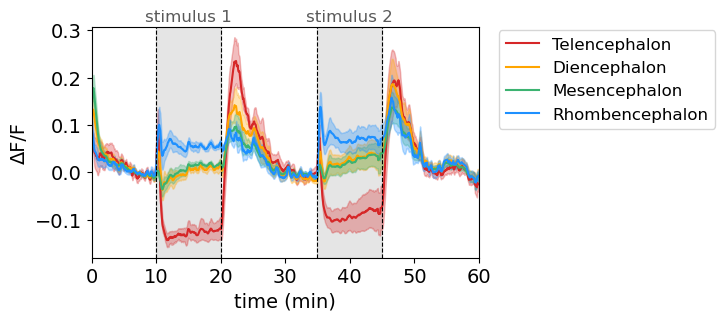

In [15]:
t = mean_df.index.to_numpy()
minutes = np.round((len(t) * 3.25) / 60)  # one frame every 3.25 seconds
x_ticklabels = np.arange(0, int(minutes) + 1, 10)
x_ticks = np.arange(0, len(t) + 2, 185)  # (10 min * 60) / 3.25 approx 185: 185 frames equal 10 min

fig, ax = plt.subplots(figsize=(5,3))

for r in regions_to_plot:
    ax.plot(t, mean_df[r], label=short_name_map[r], color=region_colors_dict[r])
    ax.fill_between(t, mean_df[r] - sem_df[r], mean_df[r] + sem_df[r], alpha=0.3, color=region_colors_dict[r])

for a, b, label in phases:
    ax.axvline(x=a, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(x=b, color='black', linewidth=0.8, linestyle='--')
    ax.axvspan(a, b, color='gray', alpha=0.2, zorder=0)
    ax.text((a + b) / 2, 1.01, label,
            ha='center', va='bottom', fontsize=12, color='0.35',
            transform=ax.get_xaxis_transform(), clip_on=False)

ax.set_xlabel('time (min)', fontsize=14)
ax.set_xlim(0, t[-1])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize=14)

ax.set_ylabel('ΔF/F', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.legend(bbox_to_anchor=(1.03, 1.02), fontsize=12)

fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)
plt.show()

**Show overlays of selected regions on top of reference brain**

In [16]:
def load_nrrd(path):
    vol, header = nrrd.read(path)
    vol = np.asarray(vol).T
    return vol, header

In [17]:
def project(vol, axis=0, mode="max"):   # axis=0 is z-axis
    if mode == "max":
        return np.max(vol, axis=axis)
    if mode == "mean":
        return np.mean(vol, axis=axis)

In [18]:
def overlay_regions_on_brain(
    brain_2d,
    region_masks_2d_dict,   # {region_name: mask2d_bool}
    region_colors_dict,     # {region_name: color_string}
    color_overlay=True,
    alpha=0.3,
    outline=False,
    outline_lw=2):

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(brain_2d, cmap="gray", interpolation="nearest")

    for region_name, mask2d in region_masks_2d_dict.items():
        color = region_colors_dict[region_name]
        rgb = np.array(mcolors.to_rgb(color))[None, None, :]
        
        if color_overlay:
            # RGBA overlay image: color where mask is True
            overlay = np.zeros((*mask2d.shape, 4), dtype=np.float32)
            overlay[..., :3] = rgb
            overlay[..., 3] = alpha * mask2d.astype(np.float32)

            ax.imshow(overlay, interpolation="nearest")

        if outline:
            # simple contour outline
            ax.contour(mask2d.astype(np.uint8), levels=[0.5], colors=[color], linewidths=outline_lw)

    ax.set_axis_off()
    return fig, ax

In [19]:
reference_brain_path = '/Users/koester_lab/Documents/Z-Brain/Elavl3-H2BRFP_z_brain.nrrd'
masks_path  = '/Users/koester_lab/Documents/Z-Brain/z_brain_regions'
# Note: masks are drawn on Ref20131120pt14pl2.nrrd (terk) but image doesn't look so nice
# for registration I used Elavl3-H2BRFP_z_brain.nrrd but masks don't fit perfectly

In [20]:
reference_brain, header = load_nrrd(reference_brain_path)

In [21]:
reference_projection = project(reference_brain)
reference_projection.shape

(1406, 621)

In [22]:
# Note: shift reference brain slightly so that masks fit better
# create black stripe for the left side and remove some stripe from the right side
black_stripe = np.zeros((1406, 10), dtype='uint16')
reference_concat = np.concatenate((black_stripe, reference_projection[:, 0:611]), axis=1)

In [23]:
region_masks_2d = {}

for r in regions_to_plot:
    mask_path = f"{masks_path}/{r}.nrrd"  
    mask_vol, _ = load_nrrd(mask_path)

    mask_vol = mask_vol > 0  # to create boolean array

    mask_proj = project(mask_vol, mode='mean') > 0
    region_masks_2d[r] = mask_proj

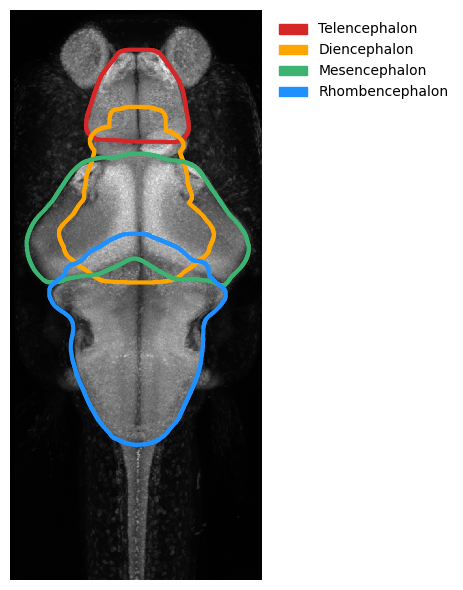

In [24]:
# legend outside
fig, ax = overlay_regions_on_brain(
    reference_concat,
    region_masks_2d_dict=region_masks_2d,
    region_colors_dict=region_colors_dict,
    color_overlay=False,
    alpha=0.3,
    outline=True,
    outline_lw=3
)

handles = [mpatches.Patch(color=region_colors_dict[r], label=short_name_map.get(r, r)) for r in regions_to_plot]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

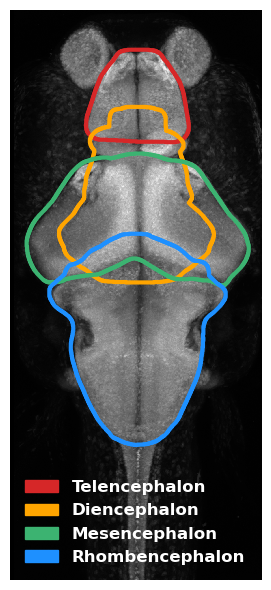

In [25]:
# legend on top of image
fig, ax = overlay_regions_on_brain(
    reference_concat,
    region_masks_2d_dict=region_masks_2d,
    region_colors_dict=region_colors_dict,
    color_overlay=False,
    alpha=0.3,
    outline=True,
    outline_lw=3
)

handles = [mpatches.Patch(color=region_colors_dict[r], label=short_name_map.get(r, r)) for r in regions_to_plot]
ax.legend(handles=handles, 
          bbox_to_anchor=(0, 0), 
          loc="lower left", 
          frameon=False, 
          labelcolor='white', 
          prop={'weight':'bold', 'size':'large'})

plt.tight_layout()
plt.show()